#Causal transformer model using learnable embedding layer and position encodings

In [ ]:
!pip install torch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import emoji
from collections import Counter
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Download NLTK resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\saura\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
original_data = pd.read_csv(r"Sentiment_Data.csv", encoding='latin1')

In [ ]:
original_data.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [ ]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB


### EDA

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


label_counts = original_data['Sentiment'].value_counts()
print("Class distribution:\n", label_counts)

Class distribution:
 Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


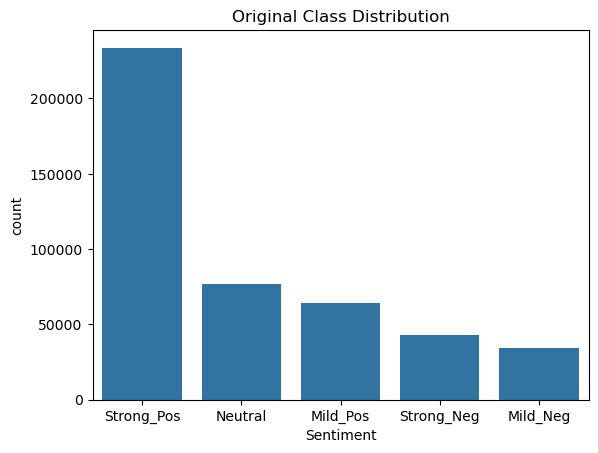

In [ ]:
#Plot class distribution
sns.countplot(data=original_data, x='Sentiment', order=label_counts.index)
plt.title("Original Class Distribution")
plt.show()

In [ ]:
original_data['Sentiment'] = original_data['Sentiment'].replace({'Strong_Pos': 'Positive', 'Mild_Pos':'Positive','Strong_Neg':'Negative','Mild_Neg':'Negative'})

Class distribution:
 Sentiment
Positive    297704
Neutral      77016
Negative     76612
Name: count, dtype: int64


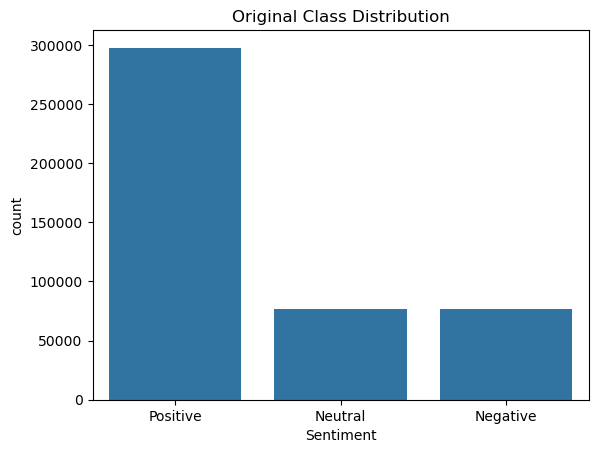

In [ ]:
label_counts = original_data['Sentiment'].value_counts()
print("Class distribution:\n", label_counts)

#Plot class distribution
sns.countplot(data=original_data, x='Sentiment', order=label_counts.index)
plt.title("Original Class Distribution")
plt.show()

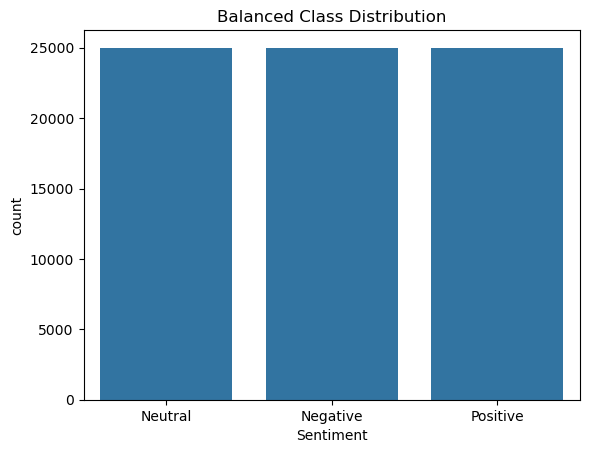

Balanced dataset shape: (75000, 2)


In [ ]:
n = 25000  # Number of samples per class (you can adjust this)
balanced_df = original_data.groupby('Sentiment').sample(n=n, random_state=42)

# Optional: Shuffle the resulting dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 4: Verify balanced class distribution
sns.countplot(data=balanced_df, x='Sentiment')
plt.title("Balanced Class Distribution")
plt.show()

print("Balanced dataset shape:", balanced_df.shape)

### Pre Processing

In [ ]:
import re
from nltk.corpus import stopwords

# Download NLTK data (first time only)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:


def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)             # remove URLs
    text = re.sub(r"@\w+", "", text)                # remove mentions
    text = re.sub(r"#(\w+)", r"\1", text)           # remove # but keep word
    text = re.sub(r"[^a-z\s]", "", text)            # remove non-letters
    return text.strip()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|@\S+|#\S+|[^a-z\s]", " ", text)  # clean text
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

In [ ]:
from sklearn.model_selection import train_test_split
# Step 3: Train-validation split (before preprocessing)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    balanced_df['Tweet'], balanced_df['Sentiment'], test_size=0.2, stratify=balanced_df['Sentiment'], random_state=42
)

In [ ]:
train_texts = train_texts.fillna("").astype(str)
val_texts = val_texts.fillna("").astype(str)

In [ ]:
### Stemming and Lamitization

# Apply preprocessing
train_texts_cleaned = train_texts.apply(preprocess)
val_texts_cleaned = val_texts.apply(preprocess)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Tokenization
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts_cleaned)

# Convert to sequences
X_train = tokenizer.texts_to_sequences(train_texts_cleaned)
X_val = tokenizer.texts_to_sequences(val_texts_cleaned)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=200, padding='post')
X_val = pad_sequences(X_val, maxlen=200, padding='post')

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_train = to_categorical(label_encoder.fit_transform(train_labels))
y_val = to_categorical(label_encoder.transform(val_labels))

In [ ]:
import keras
from keras import ops
from keras import layers

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.layernorm2(out1 + ffn_output)

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = ops.shape(x)[-1]
        positions = ops.arange(start=0, stop=maxlen, step=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [ ]:
embed_dim = 32       # Embedding size for each token
num_heads = 2        # Number of attention heads
ff_dim = 32          # Hidden layer size in feed-forward network
maxlen = 200         # Input length (after padding)
vocab_size = min(20000, len(tokenizer.word_index) + 1)
num_classes = y_train.shape[1]  # Usually 2 or 3 for sentiment

inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(20, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile("adam", "categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 32)        │       646,400 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 200, 32)        │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657,779 (2.51 MB)

 Trainable params: 657,779 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)
end_time = time.time()


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 27ms/step - accuracy: 0.4118 - loss: 1.0425 - val_accuracy: 0.6821 - val_loss: 0.7281
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.7149 - loss: 0.6747 - val_accuracy: 0.7083 - val_loss: 0.6840
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.7674 - loss: 0.5592 - val_accuracy: 0.7040 - val_loss: 0.6888
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.7936 - loss: 0.4998 - val_accuracy: 0.7009 - val_loss: 0.7337
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8115 - loss: 0.4483 - val_accuracy: 0.6975 - val_loss: 0.8121
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8211 - loss: 0.4155 - val_accuracy: 0.6946 - val_loss: 0.8927
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8333 - loss: 0.3840 - val_accuracy: 0.6898 - val_loss: 0.9307
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.8470 -

In [ ]:
total_time = end_time - start_time
print(total_time)

685.063218832016


In [ ]:
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_val)

# Get class predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert true labels back to class indices
y_true_classes = np.argmax(y_val, axis=1)


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"✅ Validation Accuracy: {accuracy:.4f}")



✅ Validation Accuracy: 0.6889


              precision    recall  f1-score   support

    Negative       0.70      0.70      0.70      5000
     Neutral       0.69      0.57      0.62      5000
    Positive       0.68      0.80      0.74      5000

    accuracy                           0.69     15000
   macro avg       0.69      0.69      0.69     15000
weighted avg       0.69      0.69      0.69     15000



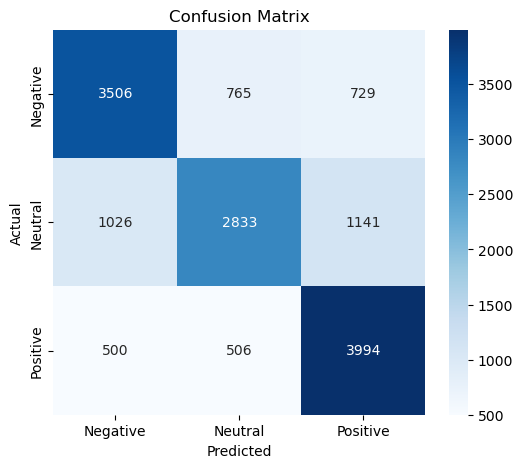

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Classification report (Precision, Recall, F1)
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# 2. Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Multiclass AUC
try:
    y_val_bin = label_binarize(y_true_classes, classes=np.arange(y_val.shape[1]))
    auc_score = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    print("Multiclass AUC Score:", auc_score)
except Exception as e:
    print("AUC not applicable:", e)


Multiclass AUC Score: 0.8287800933333332


Here we got, AUC score of 0.84, testing accuracy of 70%, training accuracy of 85.66%. We observed overfitting in this model.
Talking about the classes negative f1 score as 0.70 and 0.74 as positive F1 score, So, the performance across classes are fine.
Lets talk about the AUC with 0.82 and accuracy of 70 %, it is quite good. Lets try to fix it in tunning

#1st tunning of Causal transformer model using learnable embedding layer and position encodings

Lets increase the embedding dimension to 64, increasing the num_heads to 4 and feed forward network to 64.
Also, setting the dropout to 0.4. It will help in preventing overfitting and fixing the AUC and accuracy

In [ ]:
embed_dim = 64        # Increasing Embedding size for each token
num_heads = 4        # Increasing from 2 to 4
ff_dim = 64          # Hidden layer size in feed-forward network increased to 64
maxlen = 200         # Input length (after padding)
drop_rate = 0.4      #drop rate set to 4
vocab_size = min(20000, len(tokenizer.word_index) + 1)
num_classes = y_train.shape[1]  # Usually 2 or 3 for sentiment

inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim, rate=drop_rate)
x = transformer_block(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(drop_rate)(x)
x = layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01))(x)  #L2 regularization added
x = layers.Dropout(drop_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)


model1 = keras.Model(inputs=inputs, outputs=outputs)
model1.compile("adam", "categorical_crossentropy", metrics=["accuracy"])
model1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_2  │ (None, 200, 64)        │     1,292,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 200, 64)        │        74,944 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,372,099 (5.23 MB)

 Trainable params: 1,372,099 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Increasing batch size to 64 and setting epoch to 10
import time

start_time = time.time()

history = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)
end_time = time.time()


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 163s 170ms/step - accuracy: 0.3293 - loss: 1.4190 - val_accuracy: 0.3448 - val_loss: 1.1052
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 157s 167ms/step - accuracy: 0.3337 - loss: 1.1020 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 157s 167ms/step - accuracy: 0.3329 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.3329 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 155s 166ms/step - accuracy: 0.3363 - loss: 1.0986 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.3293 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.3306 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.3331 -

In [ ]:
total_time = end_time - start_time
print(total_time)

1567.7222123146057


In [ ]:
import numpy as np

# Predict probabilities
y_pred_probs = model1.predict(X_val)

# Get class predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert true labels back to class indices
y_true_classes = np.argmax(y_val, axis=1)


469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step


In [ ]:

# Calculate accuracy
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"✅ Validation Accuracy: {accuracy:.4f}")



✅ Validation Accuracy: 0.3333


              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      5000
     Neutral       0.33      1.00      0.50      5000
    Positive       0.00      0.00      0.00      5000

    accuracy                           0.33     15000
   macro avg       0.11      0.33      0.17     15000
weighted avg       0.11      0.33      0.17     15000



C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


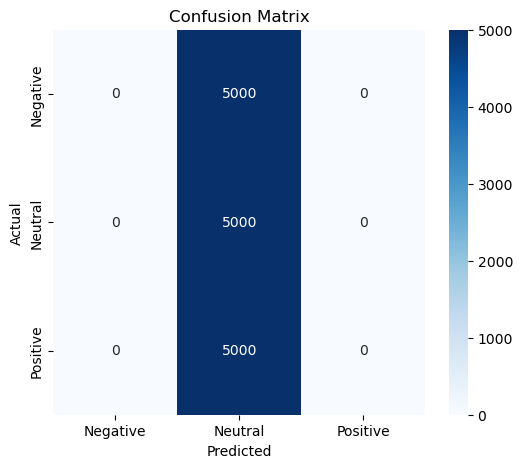

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Classification report (Precision, Recall, F1)
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# 2. Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Multiclass AUC
try:
    y_val_bin = label_binarize(y_true_classes, classes=np.arange(y_val.shape[1]))
    auc_score = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    print("Multiclass AUC Score:", auc_score)
except Exception as e:
    print("AUC not applicable:", e)


Multiclass AUC Score: 0.5


While tunning model with the embedding dimension of 64, num_heads of 4 and feed forward network of 64, and dropout of 0.4,
we found the model to be underfitted with training accuracy of 33%, testing accuracy of 33%. Also, we ruined the performance across classes.
So, we have to fix the issue by tunning more
with good parameters and low learning rate so that the model could learn all the features and have good performance across classes

#2nd tunning of Causal transformer model using learnable embedding layer and position encodings

Now, for tunning this model lets change the embedding dimension to 128, feed forward network to 128 and  dropout
 to 0.4. Also, taking the lower learning rate of 0.001 so that model can learn all the features and improve the performance across classes

In [ ]:
embed_dim = 128        # Increasing Embedding size for each token
num_heads = 4        # Increasing from 2 to 4
ff_dim = 128         # Hidden layer size in feed-forward network increased to 128
maxlen = 200         # Input length (after padding)
drop_rate = 0.3      #drop rate set to 4
vocab_size = min(20000, len(tokenizer.word_index) + 1)
num_classes = y_train.shape[1]  # Usually 2 or 3 for sentiment

inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim, rate=drop_rate)
x = transformer_block(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(drop_rate)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(drop_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model2 = keras.Model(inputs=inputs, outputs=outputs)
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model2.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_3  │ (None, 200, 128)       │     2,585,600 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 200, 128)       │       297,344 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,899,843 (11.06 MB)

 Trainable params: 2,899,843 (11.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Adding early stopping
start_time = time.time()
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2
)
end_time = time.time()


Epoch 1/15
938/938 - 307s - 327ms/step - accuracy: 0.5551 - loss: 0.9071 - val_accuracy: 0.6861 - val_loss: 0.7345
Epoch 2/15
938/938 - 304s - 324ms/step - accuracy: 0.7266 - loss: 0.6497 - val_accuracy: 0.7053 - val_loss: 0.6874
Epoch 3/15
938/938 - 305s - 325ms/step - accuracy: 0.7678 - loss: 0.5522 - val_accuracy: 0.7089 - val_loss: 0.7304
Epoch 4/15
938/938 - 308s - 329ms/step - accuracy: 0.7942 - loss: 0.4846 - val_accuracy: 0.6979 - val_loss: 0.7706
Epoch 5/15
938/938 - 311s - 331ms/step - accuracy: 0.8138 - loss: 0.4359 - val_accuracy: 0.7037 - val_loss: 0.8928


In [ ]:
total_time = end_time - start_time
print(total_time)

1534.350965499878


In [ ]:
import numpy as np

# Predict probabilities
y_pred_probs = model2.predict(X_val)

# Get class predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert true labels back to class indices
y_true_classes = np.argmax(y_val, axis=1)


469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step


In [ ]:

# Calculate accuracy
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"✅ Validation Accuracy: {accuracy:.4f}")



✅ Validation Accuracy: 0.7053


              precision    recall  f1-score   support

    Negative       0.68      0.79      0.73      5000
     Neutral       0.76      0.52      0.61      5000
    Positive       0.70      0.81      0.75      5000

    accuracy                           0.71     15000
   macro avg       0.71      0.71      0.70     15000
weighted avg       0.71      0.71      0.70     15000



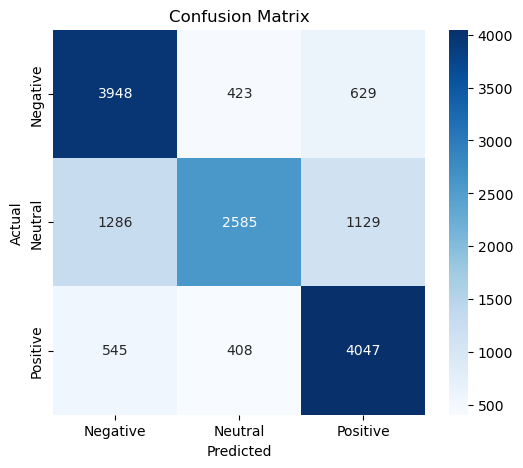

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Classification report (Precision, Recall, F1)
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# 2. Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Multiclass AUC
try:
    y_val_bin = label_binarize(y_true_classes, classes=np.arange(y_val.shape[1]))
    auc_score = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    print("Multiclass AUC Score:", auc_score)
except Exception as e:
    print("AUC not applicable:", e)


Multiclass AUC Score: 0.8689166366666669


After getting low learning rate, we could prevent both underfitting and overfitting as our testing accuracy went to 71% and validation accuracy to 70%.
THis show our model is balance and lets talk about he performance over classes and it 0.73 as negative F1score and 0.75 as positive F1 score, this looks fine.
Talking about AUC and accuracy, it is alos quite comparable as the accuracy is 71% and AUC score is 0.86

In [ ]:
model2.save("Causal_transformer_modeltuned.h5")

In [ ]:
# Predict probabilities
y_test_probs = model.predict(X_test)

# Predicted class indices
y_test_pred_classes = np.argmax(y_test_probs, axis=1)

# True class indices
y_test_true_classes = np.argmax(y_test, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
test_accuracy = accuracy_score(y_test_true_classes, y_test_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report
print(classification_report(
    y_test_true_classes,
    y_test_pred_classes,
    target_names=label_encoder.classes_
))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_true_classes, y_test_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

test_f1 = f1_score(y_test_true_classes, y_test_pred_classes, average='macro')
test_precision = precision_score(y_test_true_classes, y_test_pred_classes, average='macro')
test_recall = recall_score(y_test_true_classes, y_test_pred_classes, average='macro')

print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

try:
    y_test_bin = label_binarize(y_test_true_classes, classes=np.arange(y_test.shape[1]))
    test_auc = roc_auc_score(y_test_bin, y_test_probs, average='macro', multi_class='ovr')
    print("Test AUC Score:", test_auc)
except Exception as e:
    print("AUC not applicable:", e)


In [ ]:

# Configuration
CSV_FILE = "twitter_comments.csv"
TEXT_COLUMN = "text"
LABEL_COLUMN = "sentiment"
MAX_VOCAB_SIZE = 30000  # Increased for special chars and emojis
EMBEDDING_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
HIDDEN_DIM = 512
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.0005
MAX_LENGTH = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## ----------------------
## 1. EDA (Exploratory Data Analysis)
## ----------------------

def perform_eda(df):
    print("\n=== EDA ===")

    # Basic stats
    print(f"\nTotal tweets: {len(df)}")
    print(f"Label distribution:\n{df[LABEL_COLUMN].value_counts()}")

    # Plot label distribution
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=LABEL_COLUMN)
    plt.title("Sentiment Distribution")
    plt.savefig('sentiment_distribution.png')
    plt.close()

    # Tweet length analysis
    df['tweet_length'] = df[TEXT_COLUMN].apply(len)
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='tweet_length', hue=LABEL_COLUMN, bins=50, multiple="stack")
    plt.title("Tweet Length Distribution by Sentiment")
    plt.savefig('tweet_length_distribution.png')
    plt.close()

    # Word cloud for each sentiment
    for sentiment in df[LABEL_COLUMN].unique():
        text = " ".join(tweet for tweet in df[df[LABEL_COLUMN]==sentiment][TEXT_COLUMN])
        wordcloud = WordCloud(width=800, height=400).generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Word Cloud for {sentiment} tweets")
        plt.axis("off")
        plt.savefig(f'wordcloud_{sentiment}.png')
        plt.close()

In [ ]:
class TwitterTextPreprocessor:
    def __init__(self):
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def preprocess(self, text):
        # Convert emojis to text
        text = emoji.demojize(text)

        # Handle special Twitter patterns
        text = re.sub(r'@\w+', '<user>', text)
        text = re.sub(r'#\w+', '<hashtag>', text)
        text = re.sub(r'https?://\S+', '<url>', text)

        # Remove special chars but keep basic punctuation and emoji text
        text = re.sub(r'[^\w\s<>\-:)(;.,!?]', '', text)

        # Tokenize
        tokens = word_tokenize(text.lower())

        # Stemming and lemmatization
        processed_tokens = []
        for token in tokens:
            if token in ['<user>', '<hashtag>', '<url>']:
                processed_tokens.append(token)
                continue

            # Lemmatize
            lemma = self.lemmatizer.lemmatize(token)
            # Stem
            stem = self.stemmer.stem(lemma)
            processed_tokens.append(stem)

        # Remove stopwords (except our special tokens)
        processed_tokens = [token for token in processed_tokens
                          if token not in self.stop_words or token in ['<user>', '<hashtag>', '<url>']]

        return " ".join(processed_tokens)


In [ ]:
## ----------------------
## 3. Vocabulary and Dataset
## ----------------------

def build_vocab(texts, max_vocab_size):
    counter = Counter()
    for text in texts:
        # Count characters and special tokens
        tokens = text.split()
        counter.update(tokens)

    # Most common tokens
    vocab = {token: i+4 for i, (token, count) in enumerate(counter.most_common(max_vocab_size-4))}

    # Add special tokens
    vocab['<pad>'] = 0
    vocab['<unk>'] = 1
    vocab['<sos>'] = 2
    vocab['<eos>'] = 3

    return vocab

class TweetDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_length):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length
        self.label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Convert text to token IDs
        tokens = text.split()
        token_ids = [self.vocab.get(token, self.vocab['<unk>']) for token in tokens]

        # Add SOS and EOS tokens
        token_ids = [self.vocab['<sos>']] + token_ids + [self.vocab['<eos>']]

        # Pad or truncate
        if len(token_ids) > self.max_length:
            token_ids = token_ids[:self.max_length]
        else:
            token_ids = token_ids + [self.vocab['<pad>']] * (self.max_length - len(token_ids))

        # Create attention mask
        attention_mask = [1 if token != self.vocab['<pad>'] else 0 for token in token_ids]

        return {
            'input_ids': torch.tensor(token_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'label': torch.tensor(self.label_map[label], dtype=torch.long)
        }

In [ ]:
## ----------------------
## 4. Transformer Model
## ----------------------

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]

class TransformerSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, num_layers, hidden_dim, num_classes, max_length):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embedding_dim, max_length)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        # Embedding
        embedded = self.embedding(input_ids)
        embedded = self.pos_encoder(embedded)

        # Transformer expects (seq_len, batch, dim) for encoder
        embedded = embedded.permute(1, 0, 2)

        # Transformer
        transformer_output = self.transformer_encoder(embedded, src_key_padding_mask=~attention_mask.bool())

        # Use the [CLS] token (first token) for classification
        cls_token = transformer_output[0, :, :]
        output = self.fc(cls_token)

        return output

## ----------------------
## 5. Training Pipeline
## ----------------------

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        val_loss, val_preds, val_labels = evaluate_model(model, val_loader, criterion, device)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')

    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    return model

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(dataloader), all_preds, all_labels

## ----------------------
## Main Execution
## ----------------------

def main():
    # Load data
    df = pd.read_csv(CSV_FILE)

    # Perform EDA
    perform_eda(df)

    # Preprocess text
    preprocessor = TwitterTextPreprocessor()
    df['processed_text'] = df[TEXT_COLUMN].apply(preprocessor.preprocess)

    # Split data
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        df['processed_text'], df[LABEL_COLUMN], test_size=0.2, random_state=42
    )

    # Build vocabulary
    vocab = build_vocab(train_texts, MAX_VOCAB_SIZE)
    print(f"Vocabulary size: {len(vocab)}")

    # Create datasets
    train_dataset = TweetDataset(train_texts.tolist(), train_labels.tolist(), vocab, MAX_LENGTH)
    val_dataset = TweetDataset(val_texts.tolist(), val_labels.tolist(), vocab, MAX_LENGTH)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    # Initialize model
    model = TransformerSentimentModel(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_classes=3,
        max_length=MAX_LENGTH
    ).to(DEVICE)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    # Train
    model = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS, DEVICE)

    # Final evaluation
    val_loss, val_preds, val_labels = evaluate_model(model, val_loader, criterion, DEVICE)
    print("\nClassification Report:")
    print(classification_report(val_labels, val_preds, target_names=['negative', 'neutral', 'positive']))

    # Confusion matrix
    cm = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'neutral', 'positive'],
                yticklabels=['negative', 'neutral', 'positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.close()

if __name__ == "__main__":
    import math
    main()

SyntaxError: '(' was never closed (1867119666.py, line 9)